Agenda:[WILL START BY 9:10]
1. Load CIFAR10 dataset
2. Perform basic EDA
3. Build a simple ANN model
4. Build a CNN model

In [ ]:
import keras
import numpy as np
# Print images with their labels
import matplotlib.pyplot as plt


In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

# EDA on this data
1. Lets print 5 images from each class

In [ ]:
x_train[0].shape

(32, 32, 3)

In [ ]:
y_train[0]

array([6], dtype=uint8)

In [ ]:
label_dict =  {0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

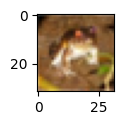

In [ ]:
plt.figure(figsize=(1,1))
plt.imshow(X_train[0])

In [ ]:
 list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

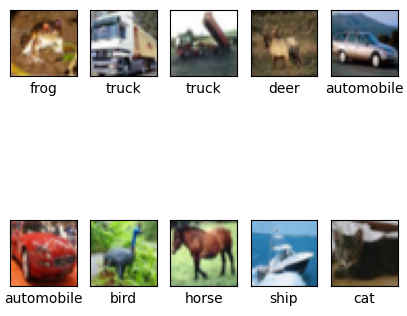

In [ ]:
# Subplot of 2 x 5 where i want to print 10 images from different class
plt.figure(figsize=(5,5))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.xlabel(label_dict.get(y_train[i][0]))

In [ ]:
# Write a function which takes the class_name and additional argument which tells number of images, and you need to print images belonging to that class

def print_image_class(class_name="frog", number=10):

  class_index = class_names.index(class_name)

  # Filter the data which had frog
  class_indices=np.where(y_train.flatten()==class_index)[0]

  #Random Samples of the class
  random_class_indices=np.random.choice(class_indices,number )



  for i in random_class_indices:
    plt.figure(figsize=(1,1))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.xlabel(label_dict.get(y_train[i][0]))
    plt.show()



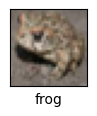

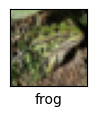

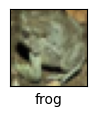

In [ ]:
print_image_class(class_name="frog", number=3)

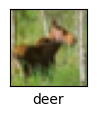

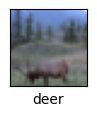

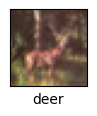

In [ ]:
print_image_class(class_name="deer", number=3)

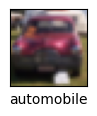

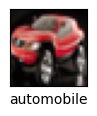

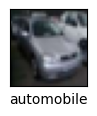

In [ ]:
print_image_class(class_name="automobile", number=3)

In [ ]:
# Resclae your data
max(X_train[00].flatten()),min(X_train[00].flatten())

# Normalize
X_train_normalize = X_train/255.0
X_test_normalize = X_test/255.0

In [ ]:
X_train[0].shape

(32, 32, 3)

In [ ]:
# Create a simple ANN model on color images
# Resclae your data
# Keras Model
# Build Keras model without flatenning the data
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32,3)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history=model.fit(X_train_normalize,y_train,epochs=5,validation_data=(X_test_normalize,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2281 - loss: 2.0941 - val_accuracy: 0.3630 - val_loss: 1.8183
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3348 - loss: 1.8439 - val_accuracy: 0.3926 - val_loss: 1.7283
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3659 - loss: 1.7654 - val_accuracy: 0.3706 - val_loss: 1.7423
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3852 - loss: 1.7209 - val_accuracy: 0.4213 - val_loss: 1.6149
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4041 - loss: 1.6766 - val_accuracy: 0.4359 - val_loss: 1.6022


In [ ]:
# Convert all the images to grayscale
X_train_gray=np.mean(X_train,axis=-1,keepdims=True)
X_test_gray=np.mean(X_test,axis=-1,keepdims=True)

In [ ]:
# Resclae your data
max(X_train_gray[00].flatten()),min(X_train_gray[00].flatten())

(np.float64(246.66666666666666), np.float64(0.0))

In [ ]:
# Normalize
X_train_gray_normalize = X_train_gray/255.0
X_test_gray_normalize = X_test_gray/255.0

In [ ]:
# Create a simple ANN model on color images
# Resclae your data
# Keras Model
# Build Keras model without flatenning the data
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32,1)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# Train the model
history=model.fit(X_train_gray_normalize,y_train,epochs=5,validation_data=(X_test_gray_normalize,y_test))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,106 (547.29 KB)

 Trainable params: 140,106 (547.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1800 - loss: 2.2136 - val_accuracy: 0.2710 - val_loss: 2.0501
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2556 - loss: 2.0647 - val_accuracy: 0.3031 - val_loss: 1.9735
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2882 - loss: 1.9943 - val_accuracy: 0.3205 - val_loss: 1.9286
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3020 - loss: 1.9531 - val_accuracy: 0.3343 - val_loss: 1.8852
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3227 - loss: 1.9110 - val_accuracy: 0.3546 - val_loss: 1.8409


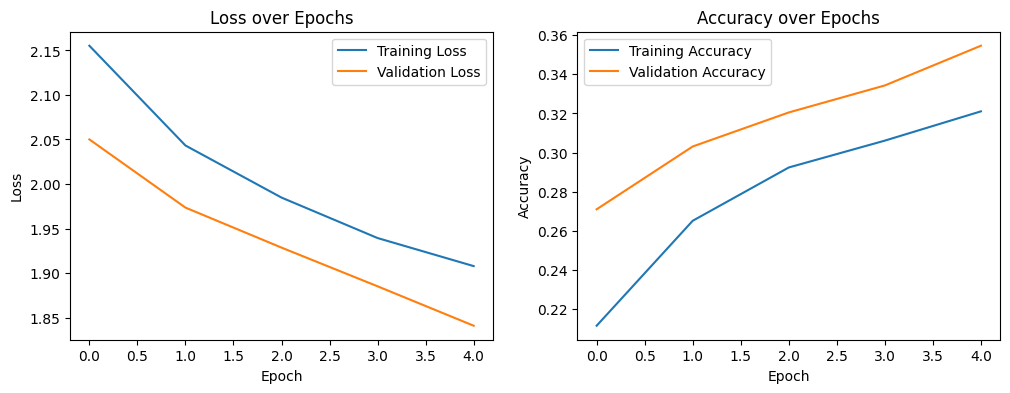

In [ ]:



plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# Create a CNN model
model = keras.Sequential([
    keras.layers.Conv2D(10,(3,3),activation='relu',input_shape=(32,32,3)),
    keras.layers.MaxPool2D((2,2)),


    keras.layers.Flatten(),


    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 5)      │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 5)      │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 3)        │           138 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,462 (13.52 KB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# Train the model
history=model.fit(X_train_normalize,y_train,epochs=5,validation_data=(X_test_normalize,y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.1116 - loss: 2.2987 - val_accuracy: 0.1892 - val_loss: 2.2231
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2150 - loss: 2.1194

KeyboardInterrupt: 